In [ ]:
import subprocess
import sys

# Activate venv
venv_path = "/ceph/home/student.aau.dk/lj02sb/Subtask2-Alexandros/inference/.venv/bin/activate_this.py"
exec(open(venv_path).read(), {'__file__': venv_path})


 # Subtask 3 Model-Prompt Heatmap

 This notebook visualizes the scores for each prompt on each model in Subtask 3 using a heatmap.

In [1]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
# Define the results directory
RESULTS_DIR = Path('../results/')


In [3]:
def load_scores(results_dir):

    data = []

    for file_path in results_dir.rglob("*.json"):

        # skip files inside the "saved" folder
        if "saved" in file_path.parts:
            continue

        try:
            with open(file_path) as f:
                metrics = json.load(f)

            filename = file_path.stem

            if "_prompt_" not in filename:
                continue

            model_name, prompt_part = filename.rsplit("_prompt_", 1)

            # if json is list
            if isinstance(metrics, list):
                metrics = metrics[0]

            # only keep evaluation files
            if "overall_score" not in metrics:
                continue

            metrics["model"] = model_name
            metrics["prompt_id"] = int(prompt_part)

            data.append(metrics)

        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    return pd.DataFrame(data)

In [ ]:
df = load_scores(RESULTS_DIR)

print(df.head())
print(df.columns)
print("Rows:", len(df))


   strict_macro_precision  strict_macro_recall  strict_macro_f1  \
0               42.457071            42.084416        38.685219   
1               44.270512            81.100649        53.238160   
2               23.750000            13.547619        15.921717   
3                6.500000             5.833333         5.694444   
4               29.442308            31.722222        25.659091   

   strict_micro_precision  strict_micro_recall  strict_micro_f1  \
0               53.982301            50.413223        52.136752   
1               34.385965            80.991736        48.275862   
2               66.666667            11.570248        19.718310   
3               35.714286             4.132231         7.407407   
4               37.037037            24.793388        29.702970   

   lenient_macro_precision  lenient_macro_recall  lenient_macro_f1  \
0                45.808442             42.084416         40.330290   
1                49.085257             81.100649      

In [ ]:
pivot_df = df.pivot_table(
    index="model",
    columns="prompt_id",
    values="overall_score",
    aggfunc="mean"
)

pivot_df = pivot_df.sort_index(axis=1)

print(pivot_df.head())

prompt_id                            0          1          2          3  \
model                                                                     
BioMistral-BioMistral-7B      0.000000   0.000000   8.163265   0.000000   
Qwen-Qwen3-32B               19.718310  14.598540  17.687075   0.000000   
Qwen-Qwen3-8B                 3.149606   6.201550   0.000000   0.000000   
anthropic-claude-sonnet-4-5  58.730159  57.843137  57.480315   0.000000   
google-gemini-2-5-flash      52.136752  50.965251  48.275862  50.581395   

prompt_id                            4          5          6          7  \
model                                                                     
BioMistral-BioMistral-7B      0.000000   0.000000   0.000000   0.000000   
Qwen-Qwen3-32B                7.407407   8.888889  16.176471   6.250000   
Qwen-Qwen3-8B                 3.149606   4.724409   1.600000   3.100775   
anthropic-claude-sonnet-4-5   0.000000        NaN  55.361596  56.744186   
google-gemini-2-5-flash 

In [ ]:
pivot_df["Average"] = pivot_df.mean(axis=1)
pivot_df.loc["Average"] = pivot_df.mean(axis=0)


In [ ]:
all_models_existing = list(pivot_df.index)

closed_models = [
    "anthropic-claude-sonnet-4-5",
    "google-gemini-3-flash-preview",
    "google-gemini-2-5-flash",
    "x-ai-grok-4-1-fast"
]

open_models = [
    
    "khazarai-Bio-8B-it",
    "Qwen-Qwen3-32B",
    "Qwen-Qwen3-8B",
    "meta-llama-Llama-3-1-8B-Instruct",
    "BioMistral-BioMistral-7B"
]

# keep only models that actually exist
closed_models = [m for m in closed_models if m in pivot_df.index]
open_models = [m for m in open_models if m in pivot_df.index]

pivot_df = pivot_df.reindex(closed_models + open_models + ["Average"])


In [ ]:
def get_avg(model):
    return pivot_df.loc[model, "Average"]

closed_sorted = sorted(closed_models, key=get_avg, reverse=True)
open_sorted = sorted(open_models, key=get_avg, reverse=True)

all_models = closed_sorted + open_sorted + ["Average"]

pivot_df = pivot_df.reindex(all_models)


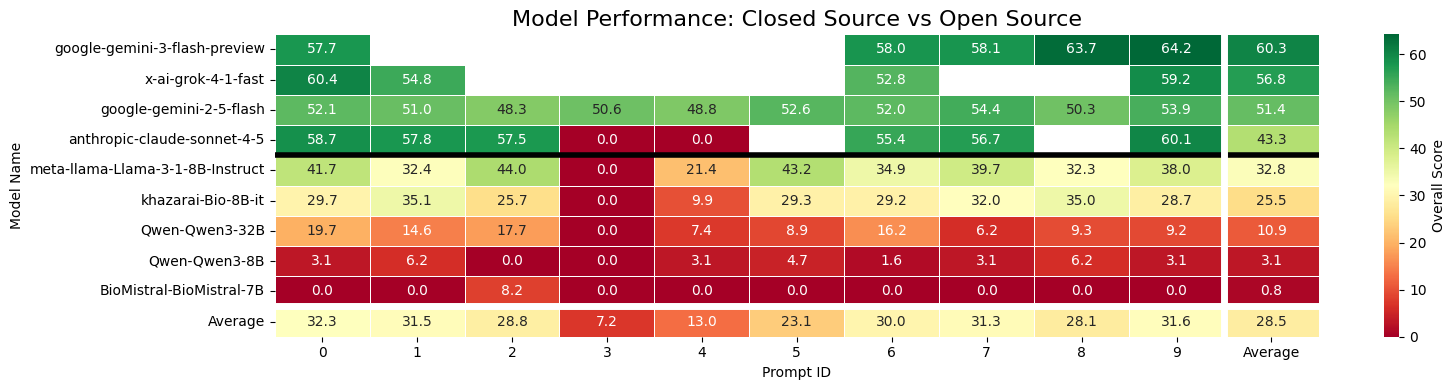

In [ ]:
plt.figure(figsize=(16, 4))

ax = sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5,
    cbar_kws={'label': 'Overall Score'}
)

sep_idx = len(closed_sorted)

ax.axhline(y=sep_idx, color='black', linewidth=4)

ax.axvline(x=pivot_df.shape[1]-1, color='white', linewidth=5)

ax.axhline(y=pivot_df.shape[0]-1, color='white', linewidth=5)

plt.title("Model Performance: Closed Source vs Open Source", fontsize=16)
plt.ylabel("Model Name")
plt.xlabel("Prompt ID")

plt.tight_layout()
plt.show()


In [ ]:
print(sorted(df["model"].unique()))

['BioMistral-BioMistral-7B', 'Qwen-Qwen3-32B', 'Qwen-Qwen3-8B', 'anthropic-claude-sonnet-4-5', 'google-gemini-2-5-flash', 'google-gemini-3-flash-preview', 'google-gemini-3-pro-preview', 'khazarai-Bio-8B-it', 'meta-llama-Llama-3-1-8B-Instruct', 'x-ai-grok-4-1-fast']


Loaded 80 dev result files.
Closed source: 4 models
Open source:   4 models


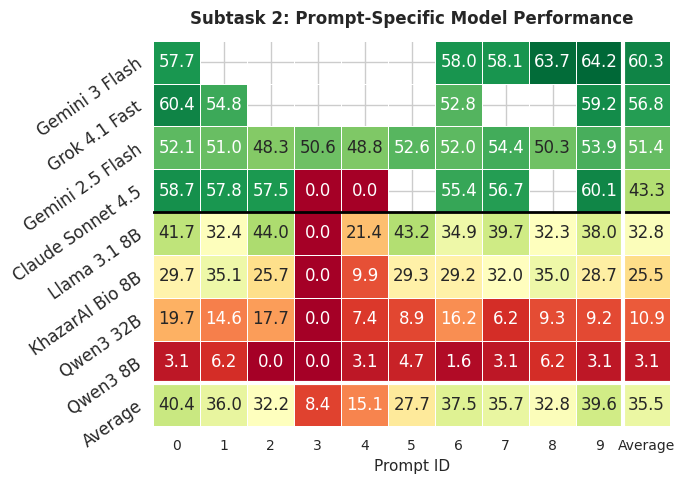

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)

# ── Dev set heatmap (Closed Source vs Open Source) ───────────────────────────
DEV_RESULTS_DIR = "../results/test"

# Note: Assumes load_scores(RESULTS_DIR) is defined elsewhere in your script
df_dev = load_scores(RESULTS_DIR)
df_dev['prompt_id'] = pd.to_numeric(df_dev['prompt_id'], errors='coerce')
df_dev = df_dev.dropna(subset=['prompt_id'])
df_dev['prompt_id'] = df_dev['prompt_id'].astype(int)
print(f"Loaded {len(df_dev)} dev result files.")

closed_source_models = [
    'anthropic-claude-sonnet-4-5',   
    'google-gemini-3-flash-preview', 
    'x-ai-grok-4-1-fast',            
    # 'google-gemini-3-pro-preview',       
    'qwen-qwen3-max',  
    'deepseek-deepseek-v3-2',
    
    'qwen-qwen3-max-thinking',  
    'google-gemini-2-5-flash'     
]

open_source_models = [
    'meta-llama-Llama-3-1-8B-Instruct', 
    'Qwen-Qwen3-32B',                   
    'google-medgemma-27b-text-it',      
    'google-medgemma-4b-it',            
    'Echelon-AI-Med-Qwen2-7B',         
    'khazarai-Bio-8B-it',
    "Qwen-Qwen3-8B",
    # "meta-llama-Llama-3-1-8B-Instruct",
 
]

# ── Define Clean Aliases for the Plot ────────────────────────────────────────
model_aliases = {
    'anthropic-claude-sonnet-4-5': 'Claude Sonnet 4.5',
    'google-gemini-3-flash-preview': 'Gemini 3 Flash',
    'x-ai-grok-4-1-fast': 'Grok 4.1 Fast',
    'google-gemini-2-5-flash': 'Gemini 2.5 Flash',
    'qwen-qwen3-max-thinking': 'Qwen3 Max Think.', 
    'qwen-qwen3-max': 'Qwen3 Max', 
    'deepseek-deepseek-v3-2':'DeepSeek V3.2',

    'google-gemini-3-pro-preview': 'Gemini 3 Pro',      
    'khazarai-Bio-8B-it': 'KhazarAI Bio 8B',

    'meta-llama-Llama-3-1-8B-Instruct': 'Llama 3.1 8B',
    'Qwen-Qwen3-32B': 'Qwen3 32B',
    'Qwen-Qwen3-8B': 'Qwen3 8B',
    'google-medgemma-27b-text-it': 'MedGemma 27B',
    'google-medgemma-4b-it': 'MedGemma 4B',
    'Echelon-AI-Med-Qwen2-7B': 'Med-Qwen2 7B',
}
# ─────────────────────────────────────────────────────────────────────────────

all_models = closed_source_models + open_source_models

# Build pivot (keep only models present in both the list and the data)
df_dev_filtered = df_dev[df_dev['model'].isin(all_models)]
pivot_dev = df_dev_filtered.pivot_table(index='model', columns='prompt_id', values='overall_score')

# Calculate Averages
pivot_dev['Average'] = pivot_dev.mean(axis=1)
pivot_dev.loc['Average'] = pivot_dev.mean(axis=0)

def get_avg_dev(model):
    try:
        return pivot_dev.loc[model, 'Average']
    except KeyError:
        return -float('inf')

# Sort
closed_sorted_dev = sorted([m for m in closed_source_models if m in pivot_dev.index], key=get_avg_dev, reverse=True)
open_sorted_dev   = sorted([m for m in open_source_models   if m in pivot_dev.index], key=get_avg_dev, reverse=True)

# Reindex using 'Average'
pivot_dev = pivot_dev.reindex(closed_sorted_dev + open_sorted_dev + ['Average'])

# Apply the clean aliases to the DataFrame index
pivot_dev.rename(index=model_aliases, inplace=True)

print(f"Closed source: {len(closed_sorted_dev)} models")
print(f"Open source:   {len(open_sorted_dev)} models")

# ── Plotting (Optimized for Legibility in Double-Column) ─────────────────────
n_closed_dev = len(closed_sorted_dev)

# Slightly taller figure to accommodate larger text without overlapping
plt.figure(figsize=(7, 5)) 

# Plot heatmap (colorbar disabled)
ax = sns.heatmap(
    pivot_dev,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    annot_kws={"size": 12}, 
    cbar=False # Removes the colorbar from the right
)

# Scale down the separator lines for the smaller figure size
ax.axhline(y=n_closed_dev, color='black', linewidth=2)
ax.axvline(x=pivot_dev.shape[1] - 1, color='white', linewidth=3)
ax.axhline(y=pivot_dev.shape[0] - 1, color='white', linewidth=3)

# Adjust titles and labels with larger, paper-appropriate font sizes
plt.title('Subtask 2: Prompt-Specific Model Performance', fontsize=12, fontweight='bold', pad=12)
plt.ylabel('') # This completely removes the "model" label
plt.xlabel('Prompt ID', fontsize=11)

# Clean up ticks and tilt the y-axis
plt.xticks(fontsize=10, rotation=0) 
# The combination of ha='right' and rotation_mode='anchor' makes sure the tilted text points exactly at the row center
plt.yticks(fontsize=12, rotation=35, ha='right', rotation_mode='anchor')

plt.tight_layout()

# Save as PDF at 300 DPI for crisp print quality
plt.savefig('subtask2_heatmap_revised.pdf', dpi=300, bbox_inches='tight')
plt.show()